# Hopper waypoint navigation with rank-based MPPI

The hopper must travel from its start (x = 0) to an **end reference point** ~20 length
units ahead. The end reference is a sphere about the size of the hopper (radius = half
its 1.25 standing height), and **intermediate points** of the same size are placed
between start and goal — their count derived from the plan horizon (spacing = the
distance coverable in one plan, floored at the sphere radius so consecutive spheres
don't fully overlap).

Planning uses **MPPIv2** for sampling, but trajectory selection replaces the plain
softmax with a **rank in [0, 1]**: 1 when a sampled trajectory's terminal torso
position is at the center of the active reference/intermediate point, 0 when it lands
outside the sphere. The top-ranked trajectory is chosen; when several share the same
high rank they are combined with a softmax. The hopper plans to the closest
intermediate point, then replans from each captured point to the next until it reaches
the end reference. The full run is rendered as an HTML video.

In [1]:
import numpy as np

from analytic_mppi.tasks.hopper import HopperTask
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2
from analytic_mppi.controllers.sampling_base import Trajectory

# ---- reference-point geometry ----
GOAL_X = 20.0            # end reference point, ~20 unitless lengths ahead of start
HOPPER_SIZE = 1.25       # hopper standing height (rootz ref in scene.xml)
R = HOPPER_SIZE / 2.0    # sphere radius: "about the size of the hopper"
WAYPOINT_Z = 1.25        # sphere centers at standing torso height

# ---- MPPI settings ----
PLAN_HORIZON = 0.8       # seconds
NUM_SAMPLES = 256
NUM_KNOTS = 6
ITERATIONS = 2
NOISE = 0.3
TEMP = 0.05
SPLINE = "cubic"
SEED = 0

# ---- task steering ----
V_NOM = 0.5              # nominal forward speed used for cost + waypoint spacing
W_POS = 3.0              # weight on the (torso_x - target_x)^2 steering term
TIE_TOL = 0.15           # ranks within this of the max count as "same high rank"
T_MAX = 60.0             # sim-time budget

## Waypoint layout — count from the plan horizon

Spacing between points is the distance the hopper can cover in one plan
(`V_NOM * PLAN_HORIZON`), floored at the sphere radius `R`. The number of
intermediate points follows from dividing the 20-unit course by that spacing.

In [2]:
spacing = max(V_NOM * PLAN_HORIZON, R)
n_segments = int(np.ceil(GOAL_X / spacing))
waypoints = np.linspace(GOAL_X / n_segments, GOAL_X, n_segments)

print(f"plan covers {V_NOM * PLAN_HORIZON:.2f} m -> spacing {spacing:.3f} m")
print(f"{n_segments - 1} intermediate points + 1 end reference at x = {GOAL_X}")
print("first five centers:", np.round(waypoints[:5], 3))

plan covers 0.40 m -> spacing 0.625 m
31 intermediate points + 1 end reference at x = 20.0
first five centers: [0.625 1.25  1.875 2.5   3.125]


## Task: steer samples toward the active point

`HopperWaypointTask` keeps the base height/orientation/velocity/control terms (so
sampled rollouts don't all faceplant) and appends a quadratic position term pulling
the torso toward the active point's center `target_x`. The outer loop mutates
`target_x` as points are captured.

In [3]:
class HopperWaypointTask(HopperTask):
    cost_term_names = HopperTask.cost_term_names + ["waypoint_cost"]

    def __init__(self, *, target_velocity, waypoint_radius, waypoint_z, w_pos):
        super().__init__(target_velocity=target_velocity)
        self.target_x = 0.0
        self.waypoint_radius = float(waypoint_radius)
        self.waypoint_z = float(waypoint_z)
        self.w_pos = float(w_pos)

    def _torso_x(self, sensordata):
        return sensordata[..., self._pos_adr]

    def _waypoint_cost(self, sensordata):
        return self.w_pos * (self._torso_x(sensordata) - self.target_x) ** 2

    def terminal_cost_terms(self, qpos, qvel, sensordata):
        base = super().terminal_cost_terms(qpos, qvel, sensordata)
        wp = self._waypoint_cost(sensordata)
        return np.concatenate([base, wp[..., None]], axis=-1)

    def running_cost_terms(self, qpos, qvel, sensordata, u):
        base = super().running_cost_terms(qpos, qvel, sensordata, u)
        wp = self._waypoint_cost(sensordata)
        return np.concatenate([base, wp[..., None]], axis=-1)

## Controller: rank in [0, 1] instead of the plain softmax

`WaypointRankMPPI` reuses MPPIv2's sampling/rollout machinery and overrides only
`update_mean`:

1. each sampled trajectory's **terminal** torso (x, z) is compared to the active
   point's center; `rank = clip(1 - dist / R, 0, 1)` — 1 at the center, 0 at or
   outside the sphere;
2. the trajectory with the highest rank (closest to the center) is chosen;
3. trajectories whose rank is within `TIE_TOL` of the max share the "same high rank"
   and are **combined with a softmax** (MPPI weights over their scores, restricted to
   the tied set);
4. if no trajectory reaches the sphere (rank all 0 — normal while the point is more
   than one plan away) there is nothing to rank, so it falls back to the standard
   MPPIv2 softmax to keep making progress.

In [4]:
class WaypointRankMPPI(MPPIv2):
    def __init__(self, *args, tie_tol=0.02, **kwargs):
        super().__init__(*args, **kwargs)
        self.tie_tol = float(tie_tol)
        self.last_rank = None
        self.last_mode = None

    def update_mean(self, traj: Trajectory) -> np.ndarray:
        adr = self.task._pos_adr
        px = traj.sensordata[:, -1, adr]        # terminal torso x, (K,)
        pz = traj.sensordata[:, -1, adr + 2]    # terminal torso z, (K,)
        dist = np.hypot(px - self.task.target_x, pz - self.task.waypoint_z)
        rank = np.clip(1.0 - dist / self.task.waypoint_radius, 0.0, 1.0)
        self.last_rank = rank

        r_max = rank.max()
        if r_max <= 0.0:                        # no sample inside the sphere yet
            self.last_mode = "softmax-fallback"
            return super().update_mean(traj)

        ties = np.flatnonzero(rank >= r_max - self.tie_tol)
        if ties.size == 1:
            self.last_mode = "best"
            return traj.knots[ties[0]].copy()

        self.last_mode = f"tie-softmax({ties.size})"
        s = traj.scores[ties]
        z = -(s - s.min()) / self.temperature
        w = np.exp(z)
        w /= w.sum()
        return (w[:, None, None] * traj.knots[ties]).sum(axis=0)

## Point-to-point replanning loop

Before moving, the hopper plans toward the **closest** intermediate point; each time
the torso comes within `R/2` of the active center the target advances to the next
point, and it replans from there — repeating until the end reference is captured.

In [5]:
task = HopperWaypointTask(target_velocity=V_NOM, waypoint_radius=R,
                          waypoint_z=WAYPOINT_Z, w_pos=W_POS)
backend = MujocoBackend(task.model_path)
ctrl = WaypointRankMPPI(task=task, backend=backend, num_samples=NUM_SAMPLES,
                        noise_level=NOISE, temperature=TEMP, num_knots=NUM_KNOTS,
                        plan_horizon=PLAN_HORIZON, spline_type=SPLINE,
                        iterations=ITERATIONS, seed=SEED, tie_tol=TIE_TOL)

wp_idx = 0
task.target_x = waypoints[wp_idx]               # closest intermediate point first
ctrl.reset()

states_hist = [backend.get_state().copy()]
torso_x_hist = [float(backend.data.qpos[0])]
captures = []                                    # (time, waypoint x) per capture
mode_counts = {}
min_height = np.inf

T = round(T_MAX / backend.dt)
for step in range(T):
    u0 = ctrl.act(backend.get_state())
    backend.step(u0)

    states_hist.append(backend.get_state().copy())
    torso_x_hist.append(float(backend.data.qpos[0]))
    mode_counts[ctrl.last_mode] = mode_counts.get(ctrl.last_mode, 0) + 1
    h = float(backend.data.sensordata[task._pos_adr + 2])
    min_height = min(min_height, h)

    t_now = (step + 1) * backend.dt
    if abs(torso_x_hist[-1] - waypoints[wp_idx]) < R / 2:
        captures.append((t_now, waypoints[wp_idx]))
        kind = "END REFERENCE" if wp_idx == len(waypoints) - 1 else f"intermediate {wp_idx}"
        print(f"t={t_now:5.2f}s  captured {kind:>15s} (x={waypoints[wp_idx]:5.2f})  "
              f"torso h={h:.2f}  mode={ctrl.last_mode}")
        wp_idx += 1
        if wp_idx == len(waypoints):
            break
        task.target_x = waypoints[wp_idx]        # replan toward the next point

states_hist = np.asarray(states_hist)
reached = wp_idx == len(waypoints)
print(f"\n{'reached the end reference' if reached else 'STOPPED SHORT'} - "
      f"{wp_idx}/{len(waypoints)} points, final torso x = {torso_x_hist[-1]:.2f}, "
      f"min torso height = {min_height:.2f}")
print("selection modes used:", dict(sorted(mode_counts.items())))

t= 0.82s  captured  intermediate 0 (x= 0.62)  torso h=1.29  mode=tie-softmax(8)
t= 1.60s  captured  intermediate 1 (x= 1.25)  torso h=1.28  mode=tie-softmax(7)
t= 2.38s  captured  intermediate 2 (x= 1.88)  torso h=1.14  mode=tie-softmax(25)
t= 3.38s  captured  intermediate 3 (x= 2.50)  torso h=1.06  mode=best
t= 4.36s  captured  intermediate 4 (x= 3.12)  torso h=0.81  mode=tie-softmax(29)
t= 5.14s  captured  intermediate 5 (x= 3.75)  torso h=0.85  mode=tie-softmax(27)
t= 5.88s  captured  intermediate 6 (x= 4.38)  torso h=1.10  mode=tie-softmax(14)
t= 6.88s  captured  intermediate 7 (x= 5.00)  torso h=1.16  mode=tie-softmax(24)
t= 7.74s  captured  intermediate 8 (x= 5.62)  torso h=1.36  mode=tie-softmax(5)
t= 9.14s  captured  intermediate 9 (x= 6.25)  torso h=0.75  mode=tie-softmax(49)
t= 9.92s  captured intermediate 10 (x= 6.88)  torso h=1.11  mode=tie-softmax(30)
t=10.80s  captured intermediate 11 (x= 7.50)  torso h=1.30  mode=tie-softmax(14)
t=11.48s  captured intermediate 12 (x= 8.1

## HTML render

The reference and intermediate points are added as translucent visual-only sites (with
an opaque dot at each center) to a render copy of the model via `MjSpec` — physics ran
on the untouched model. Blue spheres are intermediate points; the orange sphere is the
end reference. The camera tracks the torso.

In [6]:
import base64, os, tempfile

import imageio
import mujoco
from IPython.display import HTML, display


def render_waypoint_html(states, waypoints, *, width=480, height=320,
                         stride=3, min_seconds=30.0):
    spec = mujoco.MjSpec.from_file(str(task.model_path))
    for i, x in enumerate(waypoints):
        color = [0.9, 0.35, 0.1] if i == len(waypoints) - 1 else [0.2, 0.55, 0.9]
        spec.worldbody.add_site(name=f"wp_{i}", pos=[float(x), 0.0, WAYPOINT_Z],
                                size=[R, R, R],
                                rgba=color + [0.35 if i == len(waypoints) - 1 else 0.15])
        spec.worldbody.add_site(name=f"wp_center_{i}", pos=[float(x), 0.0, WAYPOINT_Z],
                                size=[0.06, 0.06, 0.06], rgba=color + [1.0])
    model = spec.compile()
    data = mujoco.MjData(model)

    qpos = states[:, 1:1 + model.nq]
    qvel = states[:, 1 + model.nq:1 + model.nq + model.nv]

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance, cam.elevation = 5.0, -18.0

    r = mujoco.Renderer(model, height=height, width=width)
    frames = []
    for qp, qv in zip(qpos[::stride], qvel[::stride]):
        data.qpos[:] = qp
        data.qvel[:] = qv
        mujoco.mj_forward(model, data)
        cam.lookat[0] = float(data.qpos[0])
        r.update_scene(data, cam)
        frames.append(r.render())
    r.close()

    fps = min(60.0, max(1.0, len(frames) / float(min_seconds)))
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as f:
        path = f.name
    imageio.mimwrite(path, np.asarray(frames), fps=fps, codec="libx264")
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    os.remove(path)
    return (f'<figure style="display:inline-block;text-align:center">'
            f'<figcaption><b>Hopper waypoint run</b> &middot; '
            f'{len(frames) / fps:.0f}s</figcaption>'
            f'<video controls autoplay loop muted width="{width}">'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
            f'</video></figure>')


display(HTML(render_waypoint_html(states_hist, waypoints)))

libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations



## Progress summary

Torso x over time: each dot is a capture of an intermediate point, and the amber band
is the end reference sphere (x = 20 ± R).

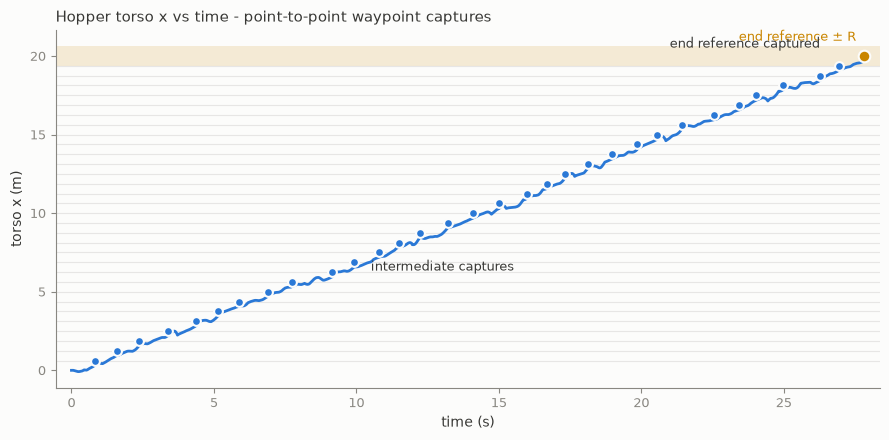

In [7]:
import matplotlib.pyplot as plt

INK, MUTED = "#383835", "#898781"
BLUE, AMBER = "#2a78d6", "#c98500"
SURFACE = "#fcfcfb"

t = np.arange(len(torso_x_hist)) * backend.dt
cap_t = np.array([c[0] for c in captures])
cap_x = np.array([c[1] for c in captures])

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.axhspan(GOAL_X - R, GOAL_X + R, color=AMBER, alpha=0.15, lw=0)
ax.text(t[-1] * 0.99, GOAL_X + R + 0.35, "end reference \u00b1 R", ha="right",
        color=AMBER, fontsize=9)
for w in waypoints[:-1]:
    ax.axhline(w, color=MUTED, alpha=0.18, lw=0.8, zorder=1)

ax.plot(t, torso_x_hist, color=BLUE, lw=2, zorder=2)
if len(cap_t):
    ax.scatter(cap_t[:-1], cap_x[:-1], s=40, color=BLUE, edgecolor=SURFACE,
               lw=1.5, zorder=3)
    ax.scatter(cap_t[-1:], cap_x[-1:], s=70, color=AMBER, edgecolor=SURFACE,
               lw=1.5, zorder=3)
    ax.annotate("intermediate captures", (cap_t[len(cap_t) // 3], cap_x[len(cap_t) // 3]),
                xytext=(12, -6), textcoords="offset points", color=INK, fontsize=9)
    ax.annotate("end reference captured", cap_t[-1:].tolist() + cap_x[-1:].tolist(),
                xytext=(-140, 6), textcoords="offset points", color=INK, fontsize=9)

ax.set_xlabel("time (s)", color=INK)
ax.set_ylabel("torso x (m)", color=INK)
ax.set_title("Hopper torso x vs time - point-to-point waypoint captures",
             color=INK, fontsize=11, loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=9)
ax.margins(x=0.02)
plt.tight_layout()
plt.show()